# V2 Projection NN Training

This notebook trains v2 projection neural networks from hotspot annotations. It writes the trained weights into `tmp/v2/models`, and `v2_01_projection.ipynb` uses those weights for projection.


In [1]:
# load project paths and local v2 modules.
from pathlib import Path
import sys
import json
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_00_projection_train import parse_hotspot_entries, train_machine_projection, train_human_projection

v2_config.ensure_v2_output_dirs()
PROJECT_ROOT


PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom')

In [2]:
# define training inputs and outputs.
MACHINE_HOTSPOT_DIR = v2_config.HOTSPOT_MACHINES_DIR
HUMAN_HOTSPOT_DIR = v2_config.HOTSPOT_PEOPLE_DIR

MACHINE_MODEL_OUTPUT = v2_config.V2_MACHINE_PROJECTION_MODEL_PATH
HUMAN_MODEL_OUTPUT = v2_config.V2_HUMAN_PROJECTION_MODEL_PATH

print('machine hotspot dir:', MACHINE_HOTSPOT_DIR)
print('human hotspot dir:', HUMAN_HOTSPOT_DIR)
print('machine model output:', MACHINE_MODEL_OUTPUT)
print('human model output:', HUMAN_MODEL_OUTPUT)


machine hotspot dir: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/hotspot_machines
human hotspot dir: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/hotspot_people_loc
machine model output: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_machine_projection_nn_model.pth
human model output: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_human_projection_nn_model.pth


In [3]:
# inspect hotspot rows before training.
machine_inputs, machine_targets = parse_hotspot_entries(MACHINE_HOTSPOT_DIR, branch='machine')
human_inputs, human_targets = parse_hotspot_entries(HUMAN_HOTSPOT_DIR, branch='human')

summary = pd.DataFrame([
    {'branch': 'machine', 'hotspot_rows': len(machine_inputs)},
    {'branch': 'human', 'hotspot_rows': len(human_inputs)},
])
display(summary)

if machine_inputs:
    display(pd.DataFrame(machine_inputs, columns=['bbox_x0', 'bbox_y0', 'bbox_x1', 'bbox_y1']).head())
    machine_target_df = pd.DataFrame(machine_targets, columns=['target_x', 'target_y'])
    machine_target_df['target_y_scaled_for_training'] = machine_target_df['target_y'] * v2_config.PROJECTION_TARGET_Y_SCALE
    display(machine_target_df.describe())
if human_inputs:
    display(pd.DataFrame(human_inputs, columns=['bbox_x0', 'bbox_y0', 'bbox_x1', 'bbox_y1']).head())
    human_target_df = pd.DataFrame(human_targets, columns=['target_x', 'target_y'])
    human_target_df['target_y_scaled_for_training'] = human_target_df['target_y'] * v2_config.PROJECTION_TARGET_Y_SCALE
    display(human_target_df.describe())


,branch,hotspot_rows
0,machine,651
1,human,85


,bbox_x0,bbox_y0,bbox_x1,bbox_y1
0,350.761414,279.518433,470.812561,369.464111
1,483.366547,135.408752,558.389038,213.964111
2,217.942642,3.648682,312.539795,48.929562
3,614.610840,286.943237,639.850830,364.623657
4,521.508545,77.812637,555.616699,91.168503


,target_x,target_y,target_y_scaled_for_training
count,651.000000,651.000000,651.000000
mean,6.269278,3.422581,2.415939
std,3.438874,1.871453,1.321025
min,0.500000,0.000000,0.000000
25%,4.500000,1.500000,1.058824
50%,6.000000,4.000000,2.823529
75%,9.000000,5.000000,3.529412
max,11.000000,8.000000,5.647059


,bbox_x0,bbox_y0,bbox_x1,bbox_y1
0,394.477234,231.197968,563.398682,481.971466
1,165.870514,255.118240,316.654449,481.147522
2,339.746246,129.752930,386.493195,272.151611
3,154.298157,233.005219,370.271667,481.848846
4,19.549484,196.755356,167.655563,479.875244


,target_x,target_y,target_y_scaled_for_training
count,85.000000,85.000000,85.000000
mean,8.051765,2.683529,1.894256
std,3.121455,1.377960,0.972677
min,2.500000,1.000000,0.705882
25%,5.500000,1.200000,0.847059
50%,9.000000,3.000000,2.117647
75%,10.500000,3.700000,2.611765
max,13.000000,6.000000,4.235294


In [4]:
# configure the training run.
RUN_MACHINE_TRAINING = True
RUN_HUMAN_TRAINING = True

training_args = SimpleNamespace(
    machine_hotspot_dir=MACHINE_HOTSPOT_DIR,
    human_hotspot_dir=HUMAN_HOTSPOT_DIR,
    machine_output=MACHINE_MODEL_OUTPUT,
    human_output=HUMAN_MODEL_OUTPUT,
    normalized_factor=v2_config.NORMALIZED_FACTOR,
    machine_epochs=80,
    human_epochs=60,
    machine_batch_size=32,
    human_batch_size=16,
    learning_rate=0.001,
    random_state=123,
    target_y_scale=v2_config.PROJECTION_TARGET_Y_SCALE,
)
training_args


namespace(machine_hotspot_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/hotspot_machines'),
          human_hotspot_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/hotspot_people_loc'),
          machine_output=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_machine_projection_nn_model.pth'),
          human_output=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_human_projection_nn_model.pth'),
          normalized_factor=640.0,
          machine_epochs=80,
          human_epochs=60,
          machine_batch_size=32,
          human_batch_size=16,
          learning_rate=0.001,
          random_state=123,
          target_y_scale=0.7058823529411765)

In [5]:
# train the projection models and save metrics.
metrics = {}
if RUN_MACHINE_TRAINING:
    metrics['machine'] = train_machine_projection(training_args)
if RUN_HUMAN_TRAINING:
    metrics['human'] = train_human_projection(training_args)

for branch, branch_metrics in metrics.items():
    print(branch)
    print('model:', branch_metrics['model_path'])
    print('test mean xy error:', branch_metrics['test']['mean_xy_error_m'])
    print('test p95 xy error:', branch_metrics['test']['p95_xy_error_m'])


machine
model: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_machine_projection_nn_model.pth
test mean xy error: 0.6906457543373108
test p95 xy error: 1.1707177400588988
human
model: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_human_projection_nn_model.pth
test mean xy error: 1.4707167148590088
test p95 xy error: 1.8372538328170775


In [6]:
# review saved training metrics.
metric_paths = {
    'machine': v2_config.V2_MACHINE_TRAINING_METRICS_JSON,
    'human': v2_config.V2_HUMAN_TRAINING_METRICS_JSON,
}

rows = []
for branch, path in metric_paths.items():
    if not path.exists():
        continue
    data = json.loads(path.read_text())
    rows.append({
        'branch': branch,
        'samples': data['sample_count'],
        'train': data['train_count'],
        'val': data['val_count'],
        'test': data['test_count'],
        'test_loss': data['test']['loss'],
        'test_mean_xy_error_m': data['test']['mean_xy_error_m'],
        'test_p95_xy_error_m': data['test']['p95_xy_error_m'],
        'target_y_scale': data.get('target_y_scale'),
        'model_path': data['model_path'],
    })

display(pd.DataFrame(rows))


,branch,samples,train,val,test,test_loss,test_mean_xy_error_m,test_p95_xy_error_m,target_y_scale,model_path
0,machine,651,494,124,33,0.468764,0.690646,1.170718,0.705882,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
1,human,85,63,17,5,0.519067,1.470717,1.837254,0.705882,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...


/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_machine_projection_training_loss.png


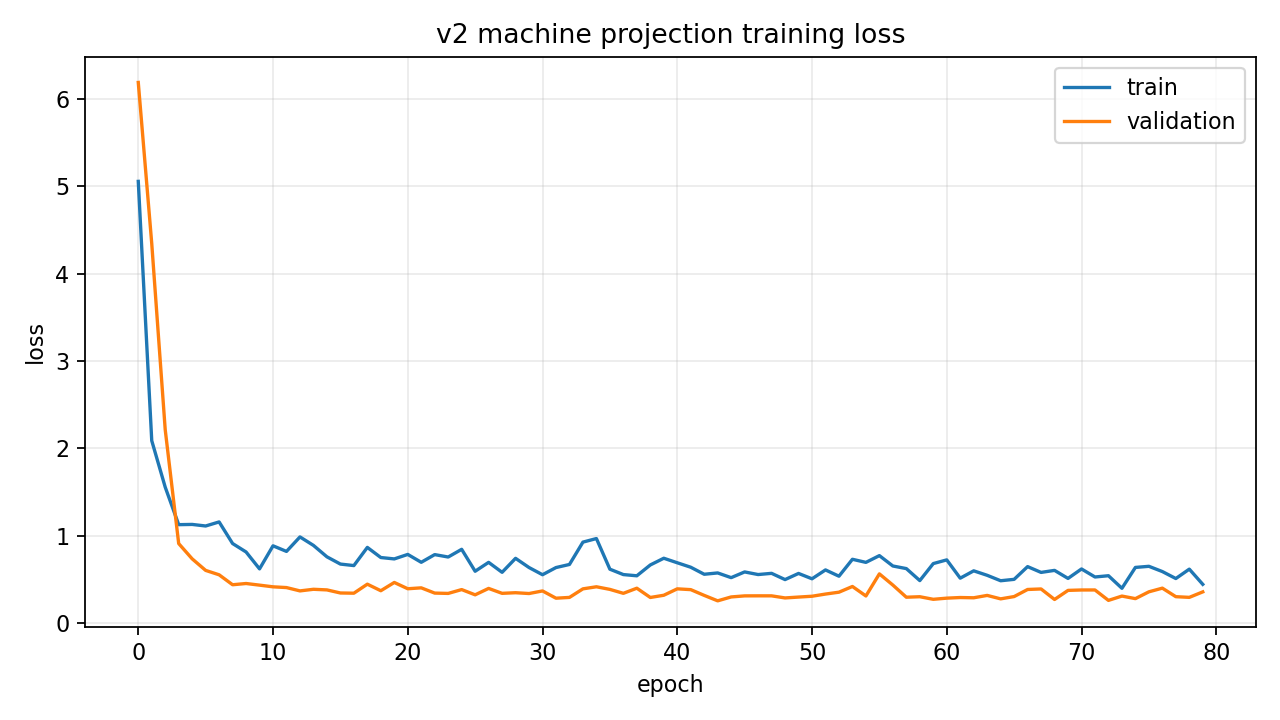

/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/models/v2_human_projection_training_loss.png


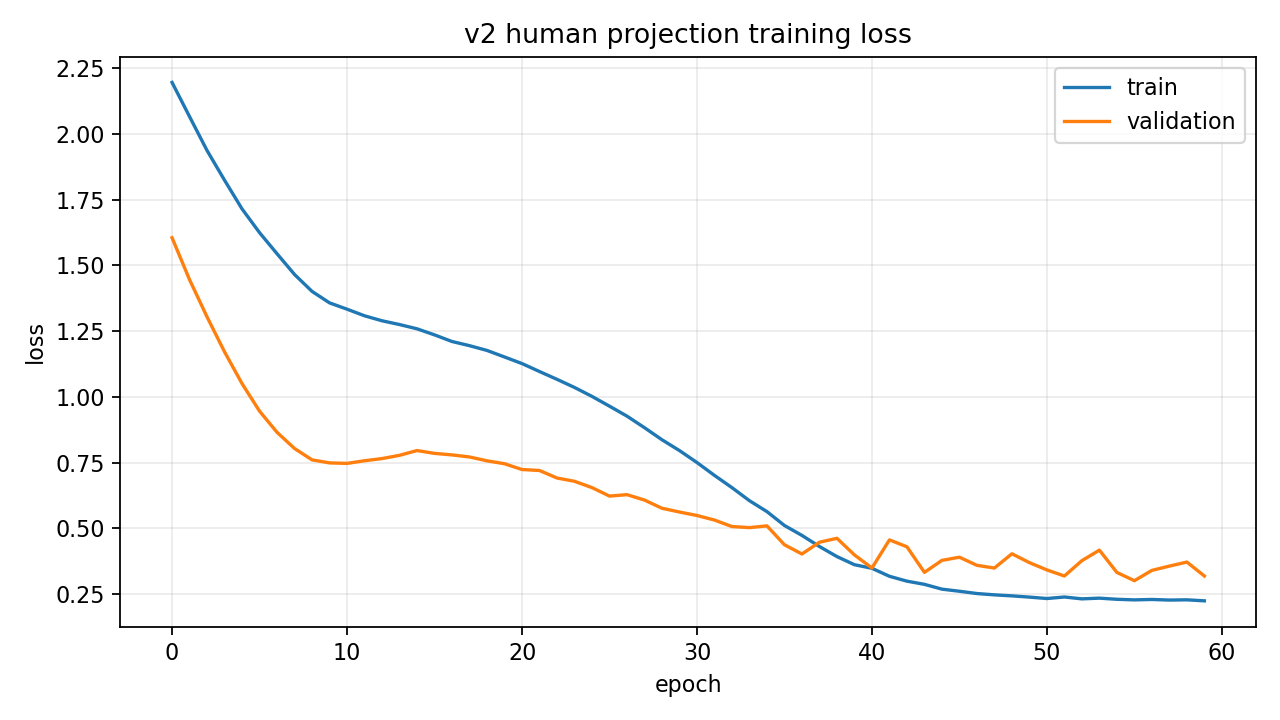

In [7]:
# display saved loss curves.
for image_path in [v2_config.V2_MACHINE_TRAINING_LOSS_PNG, v2_config.V2_HUMAN_TRAINING_LOSS_PNG]:
    if image_path.exists():
        print(image_path)
        display(Image(filename=str(image_path)))
